# Related News Graph Playground

Use `query_related_news_graph` against the local vector store and render the result as a small graph.

Before running these cells, make sure feeds have been synced and embedded into Qdrant.

In [1]:
from pathlib import Path
import sys

from dotenv import load_dotenv

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
load_dotenv(repo_root / ".env", override=True)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

repo_root

PosixPath('/Users/jackson/Codes/self/JarvisTradingLabs/open-news-mcp')

In [2]:
import html
import json

import networkx as nx
from IPython.display import SVG, display

from src.config import settings
from src.tools.query import query_related_news_graph

In [3]:
{
    "embedding_backend": settings.embedding_backend,
    "embedding_model": settings.embedding_model,
    "embedding_device": settings.embedding_device,
    "vector_backend": settings.vector_backend,
    "vector_collection": settings.vector_collection,
}

{'embedding_backend': 'local',
 'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2',
 'embedding_device': 'cpu',
 'vector_backend': 'qdrant',
 'vector_collection': 'news_articles'}

In [4]:
async def run_graph(**kwargs):
    raw = await query_related_news_graph(**kwargs)
    return json.loads(raw)


def render_graph(result, width=980, height=640):
    if not result.get("ok"):
        return result

    graph = result.get("graph", {})
    nodes = graph.get("nodes", [])
    edges = graph.get("edges", [])
    if not nodes:
        print("No graph nodes returned")
        return None

    G = nx.Graph()
    for node in nodes:
        node_id = node["id"] if node.get("kind") == "query" else node.get("node_id")
        label = node.get("label") or node.get("title") or node_id
        G.add_node(node_id, kind=node.get("kind"), label=label, data=node)

    for edge in edges:
        G.add_edge(edge["source"], edge["target"], score=float(edge.get("score", 0.0)), kind=edge.get("kind"))

    pos = nx.spring_layout(G, seed=7, weight="score")
    margin = 80

    def sx(value):
        return margin + (value + 1.0) * (width - 2 * margin) / 2.0

    def sy(value):
        return margin + (value + 1.0) * (height - 2 * margin) / 2.0

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#f7f4ef" rx="18" ry="18"/>',
    ]

    for source, target, data in G.edges(data=True):
        x1, y1 = sx(pos[source][0]), sy(pos[source][1])
        x2, y2 = sx(pos[target][0]), sy(pos[target][1])
        opacity = max(0.2, min(0.9, data.get("score", 0.0)))
        color = "#9c6b3b" if data.get("kind") == "query_match" else "#3e6b61"
        parts.append(
            f'<line x1="{x1:.1f}" y1="{y1:.1f}" x2="{x2:.1f}" y2="{y2:.1f}" stroke="{color}" stroke-opacity="{opacity:.2f}" stroke-width="2.2"/>'
        )

    for node_id, data in G.nodes(data=True):
        x, y = sx(pos[node_id][0]), sy(pos[node_id][1])
        if data.get("kind") == "query":
            radius = 30
            fill = "#c96f28"
        else:
            radius = 18
            fill = "#2f5d62"
        label = html.escape(data.get("label", node_id))
        short_label = label if len(label) <= 54 else label[:51] + "..."
        parts.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="{radius}" fill="{fill}" fill-opacity="0.92"/>')
        parts.append(
            f'<text x="{x:.1f}" y="{y + radius + 18:.1f}" text-anchor="middle" font-family="Helvetica, Arial, sans-serif" font-size="12" fill="#1f1f1f">{short_label}</text>'
        )

    parts.append('</svg>')
    display(SVG(''.join(parts)))

    return {
        "ok": True,
        "count": result.get("count"),
        "nodes": len(nodes),
        "edges": len(edges),
    }

## Macro Graph

/Users/jackson/Codes/self/JarvisTradingLabs/open-news-mcp/src/vector/providers/qdrant.py:39: UserWarning: Api key is used with an insecure connection.
  self._client = QdrantClient(
/Users/jackson/Codes/self/JarvisTradingLabs/open-news-mcp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12611.69it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


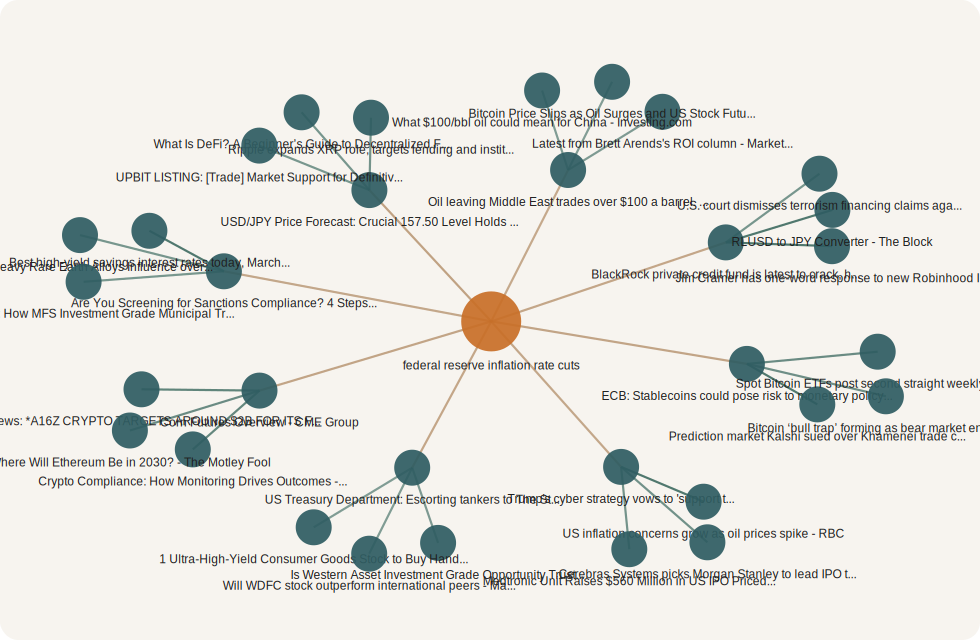

{'ok': True, 'count': 32, 'nodes': 33, 'edges': 32}

In [5]:
macro_graph = await run_graph(query="federal reserve inflation rate cuts", timespan="30d", limit=8)
render_graph(macro_graph)

## Energy Graph

In [6]:
energy_graph = await run_graph(query="opec oil production cuts crude prices", timespan="30d", limit=10)
render_graph(energy_graph)

ExpatError: not well-formed (invalid token): line 1, column 12352

## Raw Graph Payload

In [ ]:
energy_graph